# Reproducing Seaborn plots using Gadfly

In [1]:
# load packages
using DataFrames
using CSV
using StatsBase
using Gadfly
using Compose
using ColorSchemes 

In [2]:
# make directory if not exists
if !isdir("data")
    mkdir("data")
end

## 1. Grouped boxplot
https://seaborn.pydata.org/examples/grouped_boxplot.html

![](https://seaborn.pydata.org/_images/grouped_boxplot.png)

In [3]:
# download and sample data
file_name = "data/tips.csv"
if !isfile(file_name)
    download("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv", file_name)
end
tips = DataFrame(CSV.File(file_name))
tips[sample(1:nrow(tips), 7, replace = false), :]

,total_bill,tip,sex,smoker,day,time,size
,Float64,Float64,String7,String3,String7,String7,Int64
1,41.19,5.0,Male,No,Thur,Lunch,5
2,17.47,3.5,Female,No,Thur,Lunch,2
3,15.98,3.0,Female,No,Fri,Lunch,3
4,32.68,5.0,Male,Yes,Thur,Lunch,2
5,23.68,3.31,Male,No,Sun,Dinner,2
6,23.33,5.65,Male,Yes,Sun,Dinner,2
7,13.42,1.68,Female,No,Thur,Lunch,2


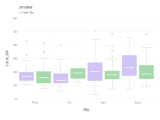

In [4]:
# visualize data
set_default_plot_size(16cm, 12cm)
plot(
    tips, 
    x = :day, 
    y = :total_bill, 
    color = :smoker, 
    Geom.boxplot, 
    Scale.x_discrete(levels = ["Thur", "Fri", "Sat", "Sun"]), 
    Scale.color_discrete_manual("#D0C4F4", "#A6D9AA", order = [2, 1]), 
    Theme(
        key_position = :top, 
        boxplot_spacing = 10px, 
        background_color = "white",
        ), 
    )

## 2. Scatterplot with varying point sizes and hues
https://seaborn.pydata.org/examples/scatter_bubbles.html

![](https://seaborn.pydata.org/_images/scatter_bubbles.png)

In [5]:
# download and sample data
file_name = "data/mpg.csv"
if !isfile(file_name)
    download("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv", file_name)
end
mpg = DataFrame(CSV.File(file_name))
mpg[sample(1:nrow(mpg), 7, replace = false), :]

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
,Float64,Int64,Float64,Float64?,Int64,Float64,Int64
1,29.0,4,90.0,70.0,1937,14.2,76
2,15.0,6,250.0,72.0,3158,19.5,75
3,21.6,4,121.0,115.0,2795,15.7,78
4,11.0,8,318.0,210.0,4382,13.5,70
5,13.0,8,400.0,190.0,4422,12.5,72
6,30.5,4,97.0,78.0,2190,14.1,77
7,33.5,4,151.0,90.0,2556,13.2,79


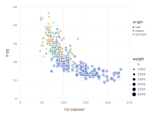

In [6]:
# visualize data
set_default_plot_size(15cm, 12cm)
plot(
    mpg,
    x = :horsepower,
    y = :mpg,
    color = :origin, 
    # shape = :origin, 
    size = :weight,
    alpha = [0.5],
    Geom.point, 
    Scale.color_discrete_manual("#5377C9", "#DF8A56", "#82CA70"), 
    Scale.size_area(
        minvalue=minimum(mpg.weight), 
        maxvalue=maximum(mpg.weight)
        ),
    Theme(
        background_color = "white", 
        default_color = "black", 
        ),
)

## 3. Annotated heatmaps
https://seaborn.pydata.org/examples/spreadsheet_heatmap.html

![](https://seaborn.pydata.org/_images/spreadsheet_heatmap.png)

In [7]:
# download and sample data
file_name = "data/flights.csv"
if !isfile(file_name)
    download("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/flights.csv", file_name)
end
flights = DataFrame(CSV.File(file_name))
flights[sample(1:nrow(flights), 7, replace = false), :]

,year,month,passengers
,Int64,String15,Int64
1,1956,June,374
2,1960,September,508
3,1955,February,233
4,1950,February,126
5,1955,November,237
6,1954,June,264
7,1949,March,132


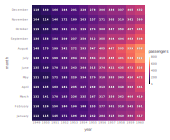

In [8]:
# visualize data
set_default_plot_size(17cm, 14cm)
plot(
    flights,
    x = :year,
    y = :month,
    color = :passengers,
    Geom.rectbin,
    Scale.ContinuousColorScale(
        palette -> get(ColorSchemes.magma, palette)
    ),
    Guide.xticks(
        ticks=[minimum(flights.year):maximum(flights.year);]
    ),
    Theme(background_color = "white"),
    Guide.annotation(
        compose(
            context(),
            text(
                flights.year,
                1:length(unique(flights.month)),
                string.(flights.passengers),
                repeat([hcenter], nrow(flights)),
                repeat([vcenter], nrow(flights)),
            ),
            fontsize(7pt),
            stroke("white"),
        ),
    )
)

## 4. Multiple linear regression
https://seaborn.pydata.org/examples/multiple_regression.html

![](https://seaborn.pydata.org/_images/multiple_regression.png)

In [9]:
# download and sample data
file_name = "data/penguins.csv"
if !isfile(file_name)
    download("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv", file_name)
end
penguins = DataFrame(CSV.File(file_name))
penguins[sample(1:nrow(penguins), 7, replace = false), :]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
,String15,String15,Float64?,Float64?,Int64?,Int64?
1,Gentoo,Biscoe,45.4,14.6,211,4800
2,Gentoo,Biscoe,45.1,14.5,215,5000
3,Chinstrap,Dream,46.9,16.6,192,2700
4,Chinstrap,Dream,53.5,19.9,205,4500
5,Gentoo,Biscoe,50.0,15.9,224,5350
6,Gentoo,Biscoe,46.8,14.3,215,4850
7,Chinstrap,Dream,50.1,17.9,190,3400


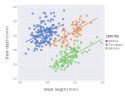

In [10]:
# visualize data
set_default_plot_size(12.5cm, 10cm)
plot(
    dropmissing(penguins, [:bill_length_mm, :bill_depth_mm]), 
    x=:bill_length_mm, 
    y=:bill_depth_mm, 
    color=:species,
    Geom.smooth(method=:lm), Geom.point, alpha=[0.6],
    Guide.xlabel("Snoot length (mm)"), 
    Guide.ylabel("Snoot  depth (mm)"), 
    Scale.color_discrete_manual("#5377C9", "#DF8A56", "#82CA70"), 
    Theme(
        background_color = "white", 
        panel_fill = "#EAEAF1", 
        grid_color = "white", 
        grid_line_width = 1.5px, 
        discrete_highlight_color = identity, 
        line_width = 2.5px, # 1mm
        ), 
    )

## 5. Multiple bivariate KDE plots¶
https://seaborn.pydata.org/examples/multiple_bivariate_kde.html

![](https://seaborn.pydata.org/_images/multiple_bivariate_kde.png)

In [11]:
# download and sample data
file_name = "data/iris.csv"
if !isfile(file_name)
    download("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv", file_name)
end
iris = DataFrame(CSV.File(file_name))
iris[sample(1:nrow(iris), 7, replace = false), :]

,sepal_length,sepal_width,petal_length,petal_width,species
,Float64,Float64,Float64,Float64,String15
1,4.9,3.1,1.5,0.1,setosa
2,4.9,3.1,1.5,0.2,setosa
3,5.5,2.4,3.8,1.1,versicolor
4,5.8,2.7,5.1,1.9,virginica
5,6.3,2.7,4.9,1.8,virginica
6,5.6,2.9,3.6,1.3,versicolor
7,5.1,2.5,3.0,1.1,versicolor


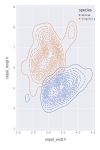

In [12]:
# visualize data
set_default_plot_size(10cm, 15cm)
plot(
    subset(iris, :species => ByRow(!=("versicolor"))), 
    x=:sepal_width, 
    y=:sepal_length, 
    color=:species, 
    Scale.color_discrete_manual("#5377C9", "#DF8A56", "#82CA70"), 
    Geom.density2d, 
    Theme(
        background_color = "white", 
        panel_fill = "#EAEAF1", 
        grid_color = "white", 
        grid_line_width = 1.5px, 
        ), 
    Guide.colorkey(pos=[0.78w,-0.42h]), 
    )

## 6. Horizontal bar plots¶
https://seaborn.pydata.org/examples/part_whole_bars.html

![](https://seaborn.pydata.org/_images/part_whole_bars.png)

In [13]:
# download and sample data
file_name = "data/car_crashes.csv"
if !isfile(file_name)
    download("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/car_crashes.csv", file_name)
end
car_crashes = DataFrame(CSV.File(file_name))
car_crashes[sample(1:nrow(car_crashes), 7, replace = false), :]

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses
,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,18.1,7.421,4.525,16.29,17.014,1053.48,133.93
2,12.0,4.2,3.36,10.92,10.68,878.41,165.63
3,12.5,4.25,4.0,8.875,12.375,1048.78,192.7
4,15.3,5.508,4.437,13.005,14.994,641.96,82.75
5,19.4,6.014,6.402,19.012,16.684,669.31,96.87
6,15.7,2.669,3.925,15.229,13.659,649.06,114.47
7,22.4,4.032,5.824,21.056,21.28,827.34,142.39


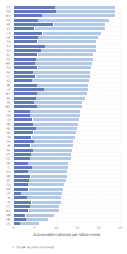

In [14]:
# visualize data
set_default_plot_size(5inch, 10inch)
p = plot(
    sort(car_crashes, :total, rev = false), 
    layer(
        x = :alcohol, 
        y = :abbrev, 
        Geom.bar(orientation = :horizontal), 
        Theme(
            default_color = color("#617BBA"), 
            bar_spacing = 3px, 
            bar_highlight = color("white")
            ), 
        ),
    layer(
        x = :total, 
        y = :abbrev, 
        Geom.bar(orientation = :horizontal), 
        Theme(
            default_color = color("#B2C8E7"), 
            bar_spacing = 3px, 
            bar_highlight = color("white"), 
            ), 
        ), 
    Guide.xlabel("Automobile collisions per billion miles"), 
    Guide.ylabel(""), 
    Guide.manual_color_key("", ["Total", "Alcohol-involved"], ["#B2C8E7", "#617BBA"]), 
    Theme(
        background_color = "white",
        key_position = :bottom, 
        ), 
)

## Scatterplot with categorical variables
https://seaborn.pydata.org/examples/scatterplot_categorical.html

![](https://seaborn.pydata.org/_images/scatterplot_categorical.png)

In [15]:
# download and sample data
file_name = "data/penguins.csv"
if !isfile(file_name)
    download("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv", file_name)
end
penguins = DataFrame(CSV.File(file_name))
penguins[sample(1:nrow(penguins), 7, replace = false), :]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
,String15,String15,Float64?,Float64?,Int64?,Int64?
1,Chinstrap,Dream,55.8,19.8,207,4000
2,Adelie,Torgersen,42.1,19.1,195,4000
3,Gentoo,Biscoe,50.4,15.7,222,5750
4,Chinstrap,Dream,50.3,20.0,197,3300
5,Gentoo,Biscoe,45.5,15.0,220,5000
6,Gentoo,Biscoe,51.3,14.2,218,5300
7,Adelie,Dream,40.2,20.1,200,3975


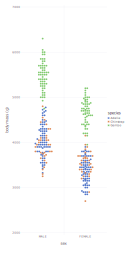

In [16]:
# visualize data
plot(
    dropmissing(penguins, [:body_mass_g, :sex, :species]), 
    x = :sex, 
    y = :body_mass_g, 
    color = :species, 
    Geom.beeswarm, 
    Scale.color_discrete_manual("#5377C9", "#DF8A56", "#82CA70"), 
    Guide.yticks(ticks = 2000:1000:7000), 
    Guide.ylabel("body mass (g)"), 
    Theme(
        background_color = "white",
        # key_position = :inside, 
    ), 
)